# 期末作业 [中等]：迁移学习实战：猫狗二分类

### 作业目标：
1.  掌握如何处理自定义图像数据集（使用 `datasets.ImageFolder`）。
2.  熟练掌握 PyTorch 的数据增强 `transforms`。
3.  **核心：** 理解并应用**迁移学习**（Transfer Learning），加载预训练模型（如 ResNet）并修改其分类头。
4.  掌握完整的项目流程：训练、验证、保存最佳模型、加载模型进行预测。

### 作业背景：
“猫狗大战”是一个经典的二分类问题。我们将使用一个大规模数据集的子集，通过迁移学习，让模型快速学会区分猫和狗。

### 教学参考：
本项目主要参考 `第七节` (ResNet) 和 `第五节` (AlexNet/VGG) 的项目结构，特别是 `train.py` 和 `predict.py` 的逻辑。

---

## 1. 准备工作：导入库与设置

我们将导入 `torchvision.models` 来获取预训练模型。

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm
import os
import json
import sys
from PIL import Image
import matplotlib.pyplot as plt

# 设置 device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. 数据准备

### 2.1. 下载并组织数据集
我们将使用 Kaggle 猫狗数据集的一个子集。请下载并解压(在学习通资料中)：


解压后，你的数据文件夹结构应该如下：
```
cats_and_dogs_filtered/
│
├── train/
│   ├── cats/ (1000 张猫的图片)
│   └── dogs/ (1000 张狗的图片)
│
└── validation/
    ├── cats/ (500 张猫的图片)
    └── dogs/ (500 张狗的图片)
```
**请在下方单元格中设置你的数据路径 `data_dir`。**

In [13]:
# TODO: 修改为你的数据路径
# 例如: "./cats_and_dogs_filtered/"
data_dir = "./cats_and_dogs_filtered/"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "validation")

assert os.path.exists(train_dir), f"路径不存在: {train_dir}"
assert os.path.exists(val_dir), f"路径不存在: {val_dir}"

### 2.2. 定义 Transforms (数据增强)

这是迁移学习的关键一步。我们使用 `ImageNet` 的均值和标准差进行归一化。
* **训练集**：需要数据增强，如 `RandomResizedCrop`, `RandomHorizontalFlip`。
* **验证集**：不需要数据增强，只需 `Resize`, `CenterCrop`。

In [14]:
data_transforms = {
    'train': transforms.Compose([
        # TODO: 为训练集添加数据增强
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        # TODO: 为验证集/测试集进行预处理
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}


### 2.3. 使用 ImageFolder 和 DataLoader

`ImageFolder` 会自动根据文件夹名称（`cats`, `dogs`）分配标签。

In [15]:
batch_size = 32

# TODO: 使用 ImageFolder 加载数据集
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=data_transforms['val'])

# TODO: 创建 DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

train_num = len(train_dataset)
val_num = len(val_dataset)
print(f"Using {train_num} images for training, {val_num} images for validation.")

# TODO: 保存类别索引
# {'cats': 0, 'dogs': 1}
class_indices = train_dataset.class_to_idx
print("Class to index mapping:", class_indices)
with open('class_indices_catsdogs.json', 'w') as f:
    json.dump(class_indices, f)

Using 2000 images for training, 1000 images for validation.
Class to index mapping: {'cats': 0, 'dogs': 1}


## 3. 构建模型 (迁移学习)

我们将使用在 ImageNet 上预训练的 `ResNet18`。
1.  加载 `models.resnet18(pretrained=True)`。
2.  **（可选）** 冻结所有层（特征提取层）的参数。
3.  **（必须）** 替换最后的全连接层 (`fc`)，使其输出维度为2（猫和狗）。

In [16]:
# TODO: 1. 加载预训练的 ResNet18
model = models.resnet18(pretrained=True)

# TODO: (可选) 冻结所有参数
for param in model.parameters():
    param.requires_grad = False

# TODO: 3. 替换全连接层
# ResNet18 的 fc 层输入维度是 512
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 2) # 2


## 4. 训练模型

我们将定义损失函数、优化器，并编写完整的训练-验证循环。

In [17]:
# TODO: 将模型移动到 device
model.to(device)

# TODO: 定义损失函数
criterion = nn.CrossEntropyLoss()

# TODO: 定义优化器
# **重要**：只将需要训练的参数（即新fc层的参数）传入优化器
# 如果你没有冻结参数，可以传入 model.parameters()
params_to_update = []
print("Params to learn:")
for name, param in model.named_parameters():
    if param.requires_grad:
        params_to_update.append(param)
        print("\t", name)

optimizer = optim.Adam(params_to_update, lr=0.001)

# 学习率衰减（可选）
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

Params to learn:
	 fc.weight
	 fc.bias


In [18]:
epochs = 10
best_acc = 0.0
save_path = './resnet18_catsdogs.pth'

print("Start Training...")

for epoch in range(epochs):
    # --- 训练 --- 
    model.train() # TODO: 设置为训练模式
    running_loss = 0.0
    train_bar = tqdm(train_loader, file=sys.stdout)
    
    for images, labels in train_bar:
        # TODO: 数据上 device
        images, labels = images.to(device), labels.to(device)
        
        # TODO: 梯度清零
        optimizer.zero_grad()
        
        # TODO: 前向传播
        outputs = model(images)
        
        # TODO: 计算损失
        loss = criterion(outputs, labels)
        
        # TODO: 反向传播
        loss.backward()
        
        # TODO: 更新参数
        optimizer.step()

        running_loss += loss.item()
        train_bar.desc = f"train epoch[{epoch + 1}/{epochs}] loss:{loss.item():.3f}"
    
    # --- 验证 ---
    model.eval() # TODO: 设置为评估模式
    acc = 0.0
    with torch.no_grad():
        val_bar = tqdm(val_loader, file=sys.stdout)
        for val_images, val_labels in val_bar:
            # TODO: 数据上 device
            val_images, val_labels = val_images.to(device), val_labels.to(device)
            
            # TODO: 前向传播
            outputs = model(val_images)
            
            # TODO: 计算准确率
            predict_y = torch.max(outputs, dim=1)[1]
            acc += torch.eq(predict_y, val_labels).sum().item()
            
            
    val_accurate = acc / val_num
    print(f"[epoch {epoch + 1}] train_loss: {running_loss / len(train_loader):.3f}  val_accuracy: {val_accurate:.3f}")

    # TODO: 保存最佳模型
    if val_accurate > best_acc:
        best_acc = val_accurate
        torch.save(model.state_dict(), save_path)
        print(f"Best model saved with accuracy: {best_acc:.3f}")

print(f"Finished Training. Best accuracy: {best_acc:.3f}")

Start Training...
100%|██████████| 32/32 [00:04<00:00,  6.91it/s]
[epoch 1] train_loss: 0.375  val_accuracy: 0.972
Best model saved with accuracy: 0.972
100%|██████████| 32/32 [00:04<00:00,  6.91it/s]
[epoch 2] train_loss: 0.221  val_accuracy: 0.979
Best model saved with accuracy: 0.979
100%|██████████| 32/32 [00:04<00:00,  6.91it/s]
[epoch 3] train_loss: 0.191  val_accuracy: 0.984
Best model saved with accuracy: 0.984
100%|██████████| 32/32 [00:04<00:00,  6.72it/s]
[epoch 4] train_loss: 0.167  val_accuracy: 0.985
Best model saved with accuracy: 0.985
100%|██████████| 32/32 [00:04<00:00,  6.58it/s]
[epoch 5] train_loss: 0.170  val_accuracy: 0.985
100%|██████████| 32/32 [00:04<00:00,  6.68it/s]
[epoch 6] train_loss: 0.181  val_accuracy: 0.981
100%|██████████| 32/32 [00:06<00:00,  5.25it/s]
[epoch 7] train_loss: 0.155  val_accuracy: 0.985
100%|██████████| 32/32 [00:06<00:00,  5.26it/s]
[epoch 8] train_loss: 0.141  val_accuracy: 0.982
100%|██████████| 32/32 [00:05<00:00,  5.45it/s]
[epoch

## 5. 模型预测（推理）

现在，我们将加载刚刚保存的最佳模型，并用它来预测一张新的图像。

In [19]:
# TODO: 1. 加载类别索引文件
try:
    with open('class_indices_catsdogs.json', 'r') as f:
        class_indices = json.load(f)
except FileNotFoundError:
    print("错误：找不到 'class_indices_catsdogs.json'。请确保训练已运行并生成了该文件。")
    class_indices = {'cats': 0, 'dogs': 1} # 手动设置以防万一
    
index_to_class = {v: k for k, v in class_indices.items()}
print("Index to class mapping:", index_to_class)

# TODO: 2. 实例化模型
# 确保模型结构与保存时一致
predict_model = models.resnet18(pretrained=False) # 不再需要加载预训练权重
in_features = predict_model.fc.in_features
predict_model.fc = nn.Linear(in_features, 2)
predict_model.to(device)

# TODO: 3. 加载我们自己训练的权重
weights_path = './resnet18_catsdogs.pth'
assert os.path.exists(weights_path), f"权重文件不存在: {weights_path}"
predict_model.load_state_dict(torch.load(weights_path, map_location=device))

# TODO: 4. 设置为评估模式
predict_model.eval()

Index to class mapping: {0: 'cats', 1: 'dogs'}


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 5.1. 编写预测函数

此函数将处理单张图像的加载、预处理和预测。

In [20]:
def predict_image(image_path):
    try:
        img = Image.open(image_path).convert('RGB')
    except FileNotFoundError:
        print(f"错误：图像文件不存在 {image_path}")
        return
    
    # TODO: 1. 应用与验证集相同的 transform
    # 注意：PIL Image -> Tensor
    img_t = data_transforms['val'](img)
    
    # TODO: 2. 增加 batch 维度 [C, H, W] -> [1, C, H, W]
    img_t = torch.unsqueeze(img_t, dim=0)
    
    # TODO: 3. 将图像移到 device
    img_t = img_t.to(device)
    
    # TODO: 4. 执行预测
    with torch.no_grad():
        output = predict_model(img_t)
        
        # TODO: 5. 转换为概率
        probabilities = torch.softmax(output, dim=1)
        
        # TODO: 6. 获取最高概率的类别
        prob, pred_index = torch.max(probabilities, dim=1)
    
    pred_index = pred_index.cpu().item()
    pred_class = index_to_class[pred_index]
    pred_prob = prob.cpu().item()

    # 可视化
    plt.imshow(img)
    plt.title(f"Prediction: {pred_class} (Prob: {pred_prob:.3f})")
    plt.axis('off')
    plt.show()
    
    print(f"图像: {image_path}")
    print(f"预测结果: {pred_class}")
    print(f"置信度: {pred_prob:.3f}")

### 5.2. 执行预测

请在验证集文件夹 `val_dir` 中找到一张猫和一张狗的图片，将它们的路径填入下方并执行预测。

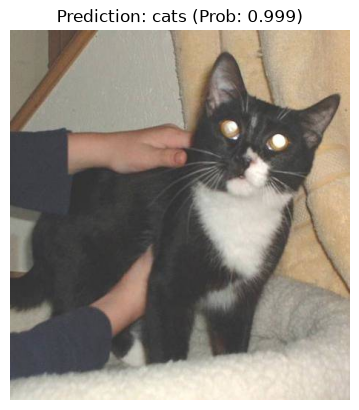

图像: ./cats_and_dogs_filtered/validation\cats\cat.2000.jpg
预测结果: cats
置信度: 0.999


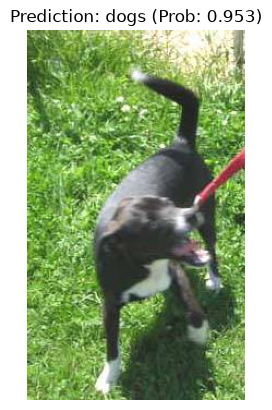

图像: ./cats_and_dogs_filtered/validation\dogs\dog.2000.jpg
预测结果: dogs
置信度: 0.953


In [21]:
# TODO: 替换为你自己的测试图片路径
# 例如: "./cats_and_dogs_filtered/validation/cats/cat.2000.jpg"
cat_image_path = os.path.join(val_dir, "cats", "cat.2000.jpg")
dog_image_path = os.path.join(val_dir, "dogs", "dog.2000.jpg")

predict_image(cat_image_path)
predict_image(dog_image_path)